# 🌿 Mulberry Leaf Quality Classifier
### Diseased vs Healthy — with Excellent / Medium / Poor grading

**Pipeline overview:**
1. Load the Kaggle dataset (4 classes: Healthy, Red Rust, Leaf Spot, Powdery Mildew)
2. Remap into a 3-class quality system:
   - `Excellent` → Healthy leaf, high confidence (≥ 0.80)
   - `Medium` → Healthy leaf, moderate confidence (< 0.80)
   - `Poor` → Any diseased leaf (Red Rust / Leaf Spot / Powdery Mildew)
3. Fine-tune a pre-trained EfficientNetB0 via transfer learning
4. Evaluate with accuracy, confusion matrix, and classification report
5. Run inference on a single new image with a quality verdict


## 1. Install & Import Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

2026-04-17 04:28:57.150390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776400137.339038      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776400137.393334      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776400137.829234      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776400137.829270      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776400137.829273      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True


## 2. Dataset Exploration

In [13]:
import os
import pandas as pd

# 1. Broadly search /kaggle/input/ for any image files
SEARCH_DIR = '/kaggle/input/'
all_classes = []

print("Searching for images...")
for root, dirs, files in os.walk(SEARCH_DIR):
    # Identify image files
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(image_files) > 0:
        # The folder name containing the images is our 'Class'
        class_name = os.path.basename(root)
        # We only want the standard classes (Healthy, Red Rust, Leaf Spot, Powdery Mildew)
        # This ignores any metadata or unexpected folders
        if any(keyword in class_name for keyword in ['Healthy', 'Rust', 'Spot', 'Mildew']):
            all_classes.append({
                'Class': class_name, 
                'Path': root, 
                'Image Count': len(image_files)
            })

# 2. Build the DataFrame
df_classes = pd.DataFrame(all_classes)

# 3. Validation & Output
if df_classes.empty:
    print("❌ STILL NO IMAGES FOUND.")
    print("Check the 'Data' tab on the right side of Kaggle. Is 'mulberry-leaf-dataset' listed?")
    # Let's list what IS there to help debug
    print(f"Items in /kaggle/input/: {os.listdir('/kaggle/input/')}")
else:
    # Set the BASE_DIR to the parent of the first class folder found
    # This ensures your later code uses the correct root path
    BASE_DIR = os.path.dirname(df_classes.iloc[0]['Path'])
    print(f"✅ Success! Data found at: {BASE_DIR}")
    print("\nDetected class folders:")
    print(df_classes[['Class', 'Image Count']].to_string(index=False))
    print(f"\nTotal images: {df_classes['Image Count'].sum()}")

Searching for images...
✅ Success! Data found at: /kaggle/input/datasets/nahiduzzaman13/mulberry-leaf-dataset/Mulberry Data

Detected class folders:
    Class  Image Count
Leaf Rust          489

Total images: 489


In [14]:
# Auto-detect the folder that contains the class sub-folders
# Works regardless of how Kaggle nests the dataset zip

def find_class_root(base):
    """
    Walk down until we find a folder whose children are all
    directories (leaf class folders).
    """
    for root, dirs, files in os.walk(base):
        subdirs = [d for d in dirs]
        if len(subdirs) >= 2:
            # Check if at least one subdir contains images
            has_images = False
            for sd in subdirs:
                sd_path = os.path.join(root, sd)
                imgs = [f for f in os.listdir(sd_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if len(imgs) > 0:
                    has_images = True
                    break
            if has_images:
                return root
    return base

DATASET_ROOT = find_class_root(BASE_DIR)
CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Dataset root detected:", DATASET_ROOT)
print("Classes found:", CLASS_NAMES)

Dataset root detected: /kaggle/input/datasets/nahiduzzaman13/mulberry-leaf-dataset/Mulberry Data
Classes found: ['Disease Free leaves', 'Leaf Rust', 'Leaf spot']


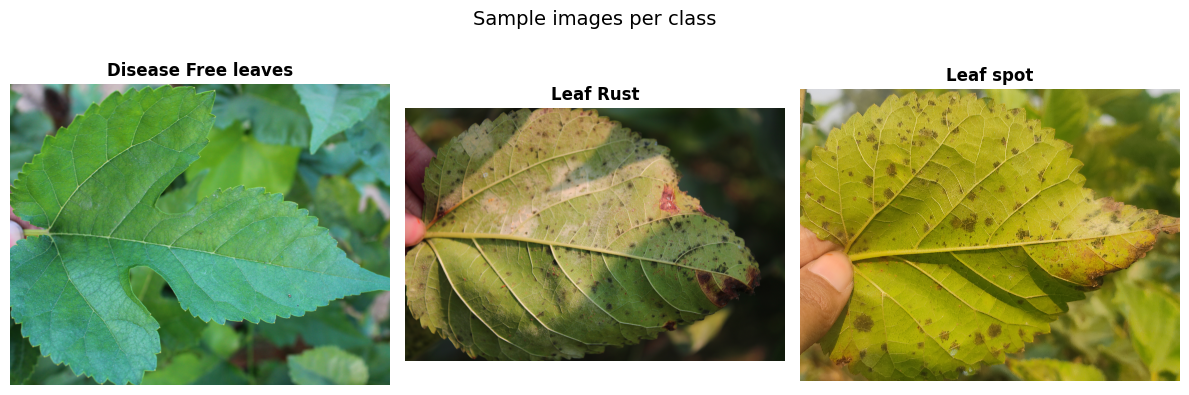

In [15]:
# Visualise one sample image from each class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(4 * len(CLASS_NAMES), 4))
if len(CLASS_NAMES) == 1:
    axes = [axes]

for ax, cls in zip(axes, CLASS_NAMES):
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_img_path = os.path.join(cls_path, imgs[0])
    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample images per class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Quality Label Mapping

We train a **4-class disease classifier** first (raw dataset labels).  
At inference time, the 4 raw predictions are collapsed into the 3-tier quality system:

| Raw class | Quality grade | Logic |
|---|---|---|
| Healthy (confidence ≥ 0.80) | **Excellent** | No disease, high certainty |
| Healthy (confidence < 0.80) | **Medium** | No disease, but uncertain |
| Red Rust / Leaf Spot / Powdery Mildew | **Poor** | Any disease detected |

In [16]:
# ----------------------------------------------------------------
# Diseased class names — adjust if your folder names differ
# The code below auto-detects: anything that is NOT 'healthy'
# (case-insensitive) is treated as diseased.
# ----------------------------------------------------------------

HEALTHY_KEYWORDS = ['healthy', 'health', 'normal', 'non_disease', 'nondisease']

def is_healthy_class(class_name):
    name_lower = class_name.lower().replace(' ', '_').replace('-', '_')
    for kw in HEALTHY_KEYWORDS:
        if kw in name_lower:
            return True
    return False

HEALTHY_CLASSES = [c for c in CLASS_NAMES if is_healthy_class(c)]
DISEASED_CLASSES = [c for c in CLASS_NAMES if not is_healthy_class(c)]

print("Healthy classes:", HEALTHY_CLASSES)
print("Diseased classes:", DISEASED_CLASSES)

if len(HEALTHY_CLASSES) == 0:
    print("\n[WARNING] Could not auto-detect healthy class.")
    print("Please set HEALTHY_CLASSES manually, e.g.:")
    print("  HEALTHY_CLASSES = ['ClassName']")
    print("  DISEASED_CLASSES = [all other classes]")

Healthy classes: []
Diseased classes: ['Disease Free leaves', 'Leaf Rust', 'Leaf spot']

[WARNING] Could not auto-detect healthy class.
Please set HEALTHY_CLASSES manually, e.g.:
  HEALTHY_CLASSES = ['ClassName']
  DISEASED_CLASSES = [all other classes]


## 4. Data Loading & Augmentation

In [17]:
# ----- Configuration -----
IMG_SIZE = 224          # EfficientNetB0 default
BATCH_SIZE = 32
EPOCHS_WARMUP = 5       # Train only top layers first
EPOCHS_FINETUNE = 20    # Then unfreeze and fine-tune
SEED = 42
CONFIDENCE_THRESHOLD = 0.80   # Healthy >= this → Excellent, else → Medium

# ----- Augmentation for training -----
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.20,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    DATASET_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

CLASS_INDICES = train_generator.class_indices   # dict: class_name -> index
INDEX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}

print("Class index mapping:", CLASS_INDICES)
print(f"Training samples : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 874 images belonging to 3 classes.
Found 217 images belonging to 3 classes.
Class index mapping: {'Disease Free leaves': 0, 'Leaf Rust': 1, 'Leaf spot': 2}
Training samples : 874
Validation samples: 217


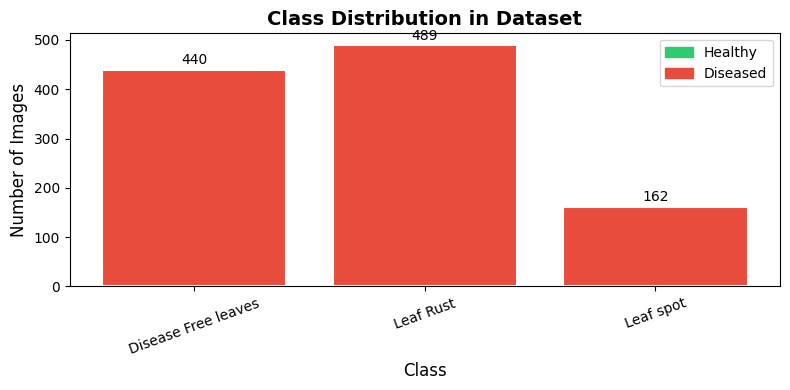

In [18]:
# Plot class distribution
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_ROOT, cls)
    n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = n

colors = ['#2ecc71' if is_healthy_class(c) else '#e74c3c' for c in class_counts.keys()]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
healthy_patch = mpatches.Patch(color='#2ecc71', label='Healthy')
disease_patch = mpatches.Patch(color='#e74c3c', label='Diseased')
ax.legend(handles=[healthy_patch, disease_patch])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Model Architecture — EfficientNetB0 Transfer Learning

In [19]:
NUM_CLASSES = len(CLASS_NAMES)

def build_model(num_classes, freeze_base=True):
    """
    EfficientNetB0 + custom classification head.
    freeze_base=True  → warm-up phase (only head trains)
    freeze_base=False → fine-tuning phase (full network trains)
    """
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = not freeze_base

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=not freeze_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

# Phase 1: warm-up
model, base_model = build_model(NUM_CLASSES, freeze_base=True)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1776401056.513815      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,398 (16.72 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 6. Training — Phase 1: Warm-up (Frozen Base)

In [20]:
callbacks_warmup = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_warmup.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_warmup = model.fit(
    train_generator,
    epochs=EPOCHS_WARMUP,
    validation_data=val_generator,
    callbacks=callbacks_warmup,
    verbose=1
)

print("\nWarm-up complete.")
print(f"Best val accuracy: {max(history_warmup.history['val_accuracy']):.4f}")

Epoch 1/5


I0000 00:00:1776401113.665730     161 service.cc:152] XLA service 0x7fc528002c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776401113.665771     161 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776401116.146240     161 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776401128.210017     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3809 - loss: 1.3705
Epoch 1: val_accuracy improved from -inf to 0.44700, saving model to /kaggle/working/best_warmup.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 370s 12s/step - accuracy: 0.3807 - loss: 1.3715 - val_accuracy: 0.4470 - val_loss: 1.1000
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3679 - loss: 1.4243
Epoch 2: val_accuracy did not improve from 0.44700
28/28 ━━━━━━━━━━━━━━━━━━━━ 265s 9s/step - accuracy: 0.3684 - loss: 1.4235 - val_accuracy: 0.4055 - val_loss: 1.0643
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4305 - loss: 1.3060
Epoch 3: val_accuracy did not improve from 0.44700
28/28 ━━━━━━━━━━━━━━━━━━━━ 280s 10s/step - accuracy: 0.4303 - loss: 1.3066 - val_accuracy: 0.4470 - val_loss: 1.0940
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3921 - loss: 1.3719
Epoch 4: val_accuracy did not improve from 0.44700
28/28 ━━━━━━━━━━━━━━━━━━━━ 281s 10s/step - accuracy: 0.3928 - loss: 1.3709 -

## 7. Training — Phase 2: Fine-tuning (Unfrozen Base)

In [21]:
# Unfreeze the last 30 layers of the base model
base_model.trainable = True
layers_to_freeze = len(base_model.layers) - 30
for layer in base_model.layers[:layers_to_freeze]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # lower LR for fine-tune
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_finetune = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3,
                      min_lr=1e-7, verbose=1)
]

# Reset generators before fine-tuning
train_generator.reset()
val_generator.reset()

history_finetune = model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_generator,
    callbacks=callbacks_finetune,
    verbose=1
)

print("\nFine-tuning complete.")
print(f"Best val accuracy: {max(history_finetune.history['val_accuracy']):.4f}")

Epoch 1/20


2026-04-17 05:05:53.120238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 05:05:53.328164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 05:05:53.770287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 05:05:53.977532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/28 ━━━━━━━━━━━━━━━━━━━━ 17:23 39s/step - accuracy: 0.3438 - loss: 1.7393

2026-04-17 05:06:08.222466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 05:06:08.428201: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 05:06:08.824654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 05:06:09.030333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4054 - loss: 1.6609
Epoch 1: val_accuracy improved from -inf to 0.44700, saving model to /kaggle/working/best_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 351s 12s/step - accuracy: 0.4055 - loss: 1.6606 - val_accuracy: 0.4470 - val_loss: 1.1061 - learning_rate: 1.0000e-04
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4003 - loss: 1.5312
Epoch 2: val_accuracy did not improve from 0.44700
28/28 ━━━━━━━━━━━━━━━━━━━━ 295s 11s/step - accuracy: 0.4013 - loss: 1.5311 - val_accuracy: 0.4470 - val_loss: 1.1122 - learning_rate: 1.0000e-04
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3869 - loss: 1.6160
Epoch 3: val_accuracy did not improve from 0.44700
28/28 ━━━━━━━━━━━━━━━━━━━━ 294s 11s/step - accuracy: 0.3867 - loss: 1.6149 - val_accuracy: 0.4470 - val_loss: 1.0940 - learning_rate: 1.0000e-04
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3978 - loss: 1.5427
Epoch 4: val_accuracy did not improve fr

## 8. Training Curves

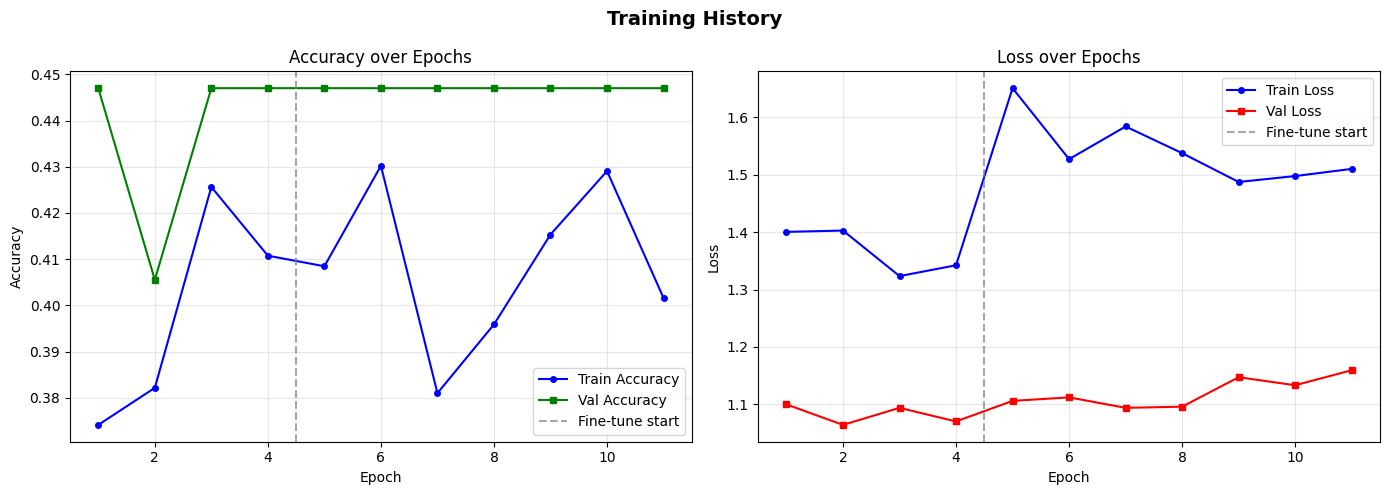

In [22]:
# Combine both phases
all_acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
all_val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']
all_loss = history_warmup.history['loss'] + history_finetune.history['loss']
all_val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

warmup_end = len(history_warmup.history['accuracy'])
epochs_total = range(1, len(all_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_total, all_acc, 'b-o', markersize=4, label='Train Accuracy')
ax1.plot(epochs_total, all_val_acc, 'g-s', markersize=4, label='Val Accuracy')
ax1.axvline(x=warmup_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_total, all_loss, 'b-o', markersize=4, label='Train Loss')
ax2.plot(epochs_total, all_val_loss, 'r-s', markersize=4, label='Val Loss')
ax2.axvline(x=warmup_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss over Epochs')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluation — Confusion Matrix & Classification Report

7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step
Raw Disease Classification Report (4-class)
                     precision    recall  f1-score   support

Disease Free leaves       0.00      0.00      0.00        88
          Leaf Rust       0.45      1.00      0.62        97
          Leaf spot       0.00      0.00      0.00        32

           accuracy                           0.45       217
          macro avg       0.15      0.33      0.21       217
       weighted avg       0.20      0.45      0.28       217



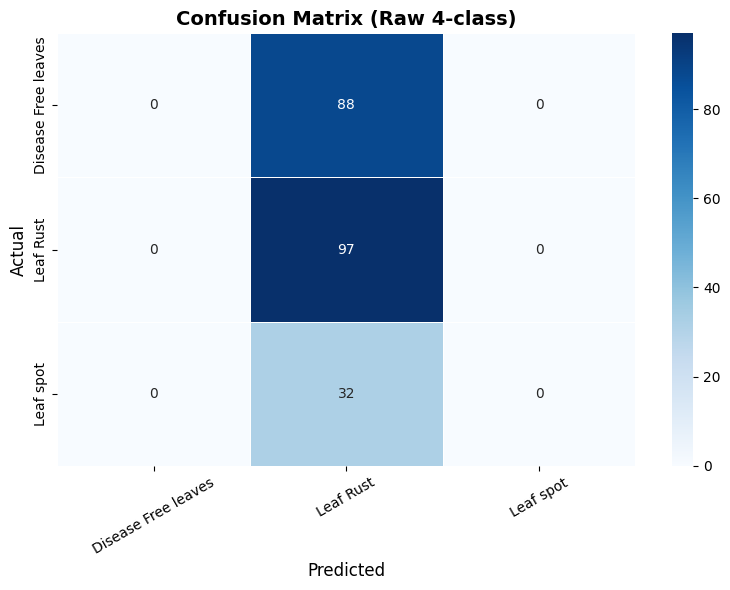

In [23]:
# Load best saved model
model = keras.models.load_model('/kaggle/working/best_model.keras')

val_generator.reset()
preds_proba = model.predict(val_generator, verbose=1)
preds_class = np.argmax(preds_proba, axis=1)
true_class = val_generator.classes

# --- Classification report (raw 4-class) ---
raw_labels = [INDEX_TO_CLASS[i] for i in range(NUM_CLASSES)]
print("=" * 60)
print("Raw Disease Classification Report (4-class)")
print("=" * 60)
print(classification_report(true_class, preds_class, target_names=raw_labels))

# --- Confusion matrix ---
cm = confusion_matrix(true_class, preds_class)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=raw_labels, yticklabels=raw_labels,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Raw 4-class)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Quality Grade Breakdown on Validation Set
  Excellent: 0 images
  Medium: 0 images
  Poor: 217 images


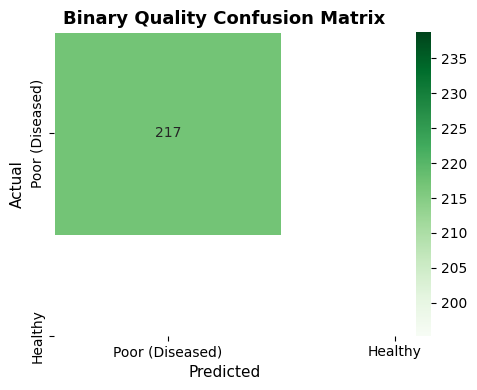

In [24]:
# --- Map to Quality grades ---
# Identify index of each healthy class
healthy_indices = set()
for cls in HEALTHY_CLASSES:
    if cls in CLASS_INDICES:
        healthy_indices.add(CLASS_INDICES[cls])

def get_quality_label(pred_class_idx, pred_proba_row, threshold=CONFIDENCE_THRESHOLD):
    """
    Convert raw model output to quality grade.
    """
    if pred_class_idx in healthy_indices:
        confidence = pred_proba_row[pred_class_idx]
        if confidence >= threshold:
            return 'Excellent'
        else:
            return 'Medium'
    else:
        return 'Poor'

# Map predictions
pred_quality = [get_quality_label(preds_class[i], preds_proba[i])
                for i in range(len(preds_class))]

# Map ground truth (any healthy class → Excellent for ground truth)
true_quality = []
for t in true_class:
    if t in healthy_indices:
        true_quality.append('Excellent')  # treat all healthy as Excellent in GT
    else:
        true_quality.append('Poor')

quality_labels = ['Excellent', 'Medium', 'Poor']

print("=" * 60)
print("Quality Grade Breakdown on Validation Set")
print("=" * 60)
from collections import Counter
pred_counts = Counter(pred_quality)
for grade in quality_labels:
    print(f"  {grade}: {pred_counts.get(grade, 0)} images")

# Quality confusion matrix (binary: healthy vs diseased)
binary_pred = [0 if q == 'Poor' else 1 for q in pred_quality]
binary_true = [0 if t in [CLASS_INDICES[c] for c in DISEASED_CLASSES if c in CLASS_INDICES] else 1 for t in true_class]

cm_bin = confusion_matrix(binary_true, binary_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Poor (Diseased)', 'Healthy'],
            yticklabels=['Poor (Diseased)', 'Healthy'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Binary Quality Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Inference Function — Quality Grading on a New Image

In [25]:
def predict_leaf_quality(image_path, model, class_indices, healthy_classes,
                         img_size=224, confidence_threshold=0.80):
    """
    Takes a path to any leaf image.
    Returns a quality verdict: Excellent / Medium / Poor.

    Parameters
    ----------
    image_path         : str   — path to the input image
    model              : keras Model
    class_indices      : dict  — {class_name: index} from training generator
    healthy_classes    : list  — names of healthy folder(s)
    img_size           : int   — model input size (default 224)
    confidence_threshold : float — above this → Excellent, below → Medium

    Returns
    -------
    result : dict with keys:
        'quality'        : 'Excellent' | 'Medium' | 'Poor'
        'is_diseased'    : bool
        'raw_class'      : predicted class name
        'confidence'     : confidence for the predicted class
        'all_probs'      : dict of {class_name: probability}
    """
    # 1. Load and preprocess
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    img_norm = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_norm, axis=0)    # shape: (1, H, W, 3)

    # 2. Predict
    proba = model.predict(img_batch, verbose=0)[0]  # shape: (num_classes,)
    pred_idx = int(np.argmax(proba))
    idx_to_cls = {v: k for k, v in class_indices.items()}
    pred_class_name = idx_to_cls[pred_idx]
    pred_confidence = float(proba[pred_idx])

    # 3. Determine healthy indices
    h_indices = set()
    for hc in healthy_classes:
        if hc in class_indices:
            h_indices.add(class_indices[hc])

    # 4. Map to quality
    is_diseased = (pred_idx not in h_indices)
    if is_diseased:
        quality = 'Poor'
    elif pred_confidence >= confidence_threshold:
        quality = 'Excellent'
    else:
        quality = 'Medium'

    # 5. All probabilities
    all_probs = {idx_to_cls[i]: round(float(proba[i]), 4) for i in range(len(proba))}

    return {
        'quality': quality,
        'is_diseased': is_diseased,
        'raw_class': pred_class_name,
        'confidence': pred_confidence,
        'all_probs': all_probs
    }


def display_prediction(image_path, result):
    """Visualise the image alongside the prediction verdict."""
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    quality_colors = {'Excellent': '#2ecc71', 'Medium': '#f39c12', 'Poor': '#e74c3c'}
    quality_icons  = {'Excellent': '✅', 'Medium': '⚠️', 'Poor': '❌'}
    q = result['quality']

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: image
    ax_img.imshow(img_rgb)
    ax_img.set_title(
        f"{quality_icons[q]} Quality: {q}   |   Raw class: {result['raw_class']}\n"
        f"Confidence: {result['confidence']:.2%}   |   Diseased: {result['is_diseased']}",
        fontsize=12, fontweight='bold',
        color=quality_colors[q]
    )
    ax_img.axis('off')

    # Right: probability bars
    classes = list(result['all_probs'].keys())
    probs = list(result['all_probs'].values())
    bar_colors = ['#e74c3c' if not is_healthy_class(c) else '#2ecc71' for c in classes]
    bars = ax_bar.barh(classes, probs, color=bar_colors, edgecolor='white')
    for bar_item, prob in zip(bars, probs):
        ax_bar.text(bar_item.get_width() + 0.01, bar_item.get_y() + bar_item.get_height() / 2,
                    f'{prob:.2%}', va='center', fontsize=10)
    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel('Probability')
    ax_bar.set_title('Class Probabilities', fontsize=12, fontweight='bold')
    ax_bar.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 50)
    print(f"  QUALITY VERDICT : {quality_icons[q]} {q}")
    print("=" * 50)
    if q == 'Excellent':
        print("  The leaf is HEALTHY with HIGH confidence.")
        print("  → Suitable for silkworm feeding. Top-grade quality.")
    elif q == 'Medium':
        print("  The leaf appears HEALTHY but confidence is moderate.")
        print("  → Usable, but inspect manually before use.")
    else:
        print(f"  Disease detected: {result['raw_class']}")
        print("  → NOT suitable. Leaf should be discarded.")
    print("=" * 50)


print("Inference functions defined successfully.")

Inference functions defined successfully.


## 11. Demo — Run Inference on Sample Images


Input class: Disease Free leaves


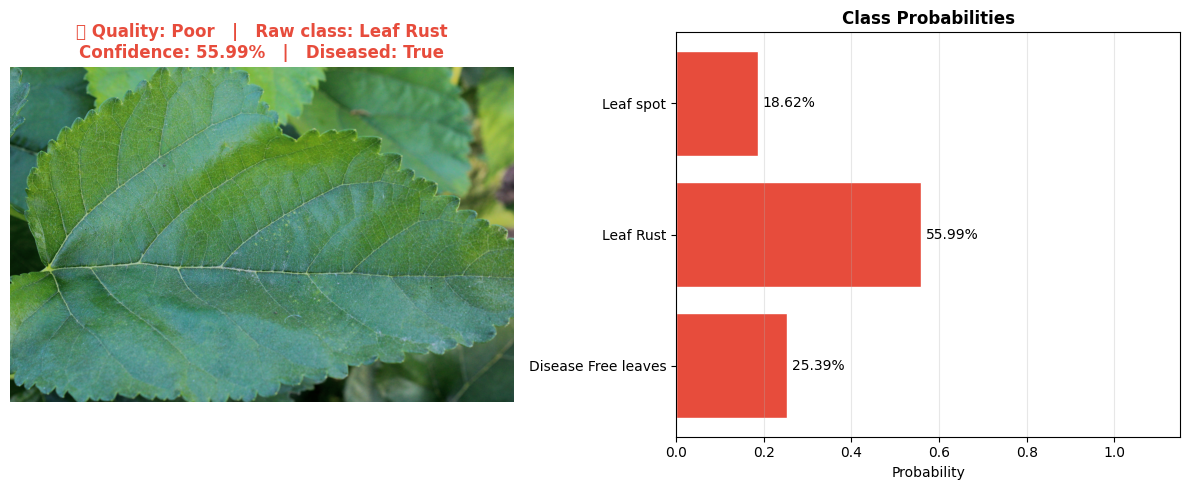


  QUALITY VERDICT : ❌ Poor
  Disease detected: Leaf Rust
  → NOT suitable. Leaf should be discarded.

Input class: Leaf Rust


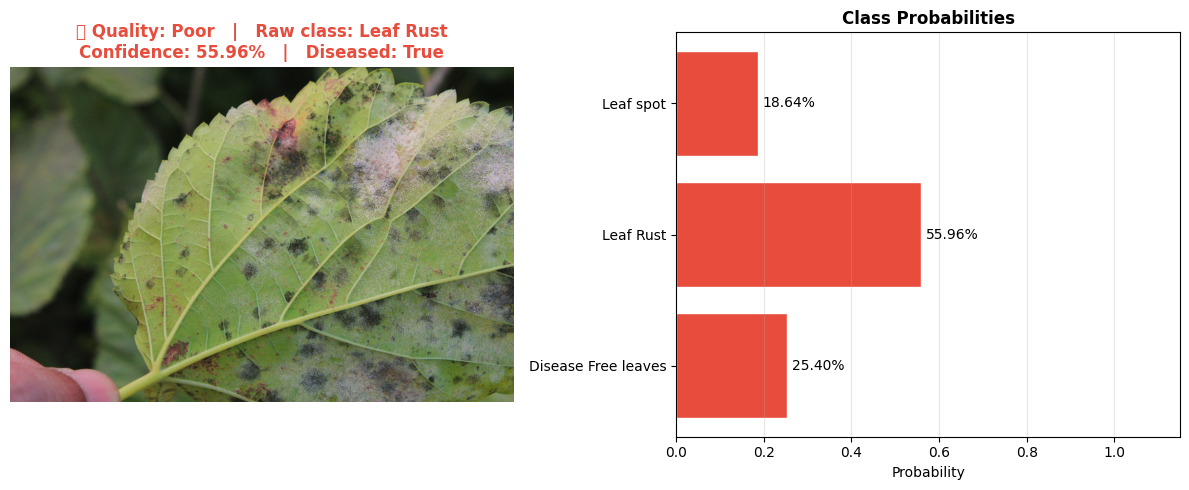


  QUALITY VERDICT : ❌ Poor
  Disease detected: Leaf Rust
  → NOT suitable. Leaf should be discarded.

Input class: Leaf spot


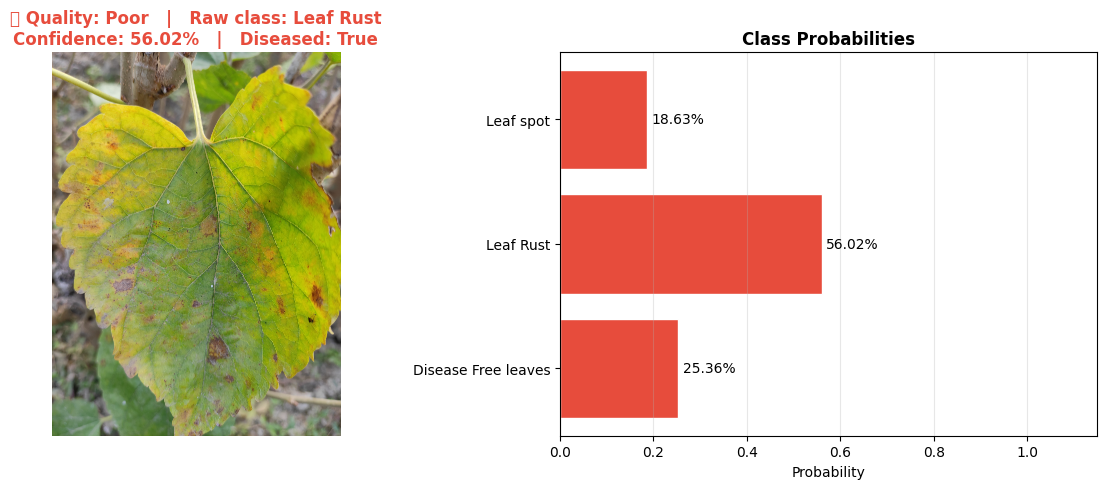


  QUALITY VERDICT : ❌ Poor
  Disease detected: Leaf Rust
  → NOT suitable. Leaf should be discarded.


In [26]:
# -------------------------------------------------------
# Demo: pick one image from each class and run inference
# -------------------------------------------------------
demo_images = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(imgs) > 5:
        demo_images[cls] = os.path.join(cls_path, imgs[5])   # pick 6th image as demo

for cls_name, img_path in demo_images.items():
    print(f"\n{'='*60}")
    print(f"Input class: {cls_name}")
    result = predict_leaf_quality(
        image_path=img_path,
        model=model,
        class_indices=CLASS_INDICES,
        healthy_classes=HEALTHY_CLASSES,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD
    )
    display_prediction(img_path, result)

## 12. Predict Your Own Image

Upload any mulberry leaf image to `/kaggle/working/` and update the path below.

In [ ]:
# -------------------------------------------------------
# CHANGE THIS PATH to your own uploaded image
# -------------------------------------------------------
MY_IMAGE_PATH = '/kaggle/working/my_leaf.jpg'

if os.path.exists(MY_IMAGE_PATH):
    result = predict_leaf_quality(
        image_path=MY_IMAGE_PATH,
        model=model,
        class_indices=CLASS_INDICES,
        healthy_classes=HEALTHY_CLASSES,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD
    )
    display_prediction(MY_IMAGE_PATH, result)
else:
    print(f"[INFO] No custom image found at '{MY_IMAGE_PATH}'.")
    print("Upload a leaf image to /kaggle/working/ and update MY_IMAGE_PATH above.")

## 13. Save the Model

In [27]:
# Save in both formats
model.save('/kaggle/working/mulberry_quality_classifier.keras')
model.save('/kaggle/working/mulberry_quality_classifier.h5')

# Save class indices for future use
import json
meta = {
    'class_indices': CLASS_INDICES,
    'healthy_classes': HEALTHY_CLASSES,
    'diseased_classes': DISEASED_CLASSES,
    'img_size': IMG_SIZE,
    'confidence_threshold': CONFIDENCE_THRESHOLD
}
with open('/kaggle/working/model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("Model and metadata saved to /kaggle/working/")
print("Files:")
for fname in ['mulberry_quality_classifier.keras',
              'mulberry_quality_classifier.h5',
              'model_metadata.json']:
    full_path = f'/kaggle/working/{fname}'
    if os.path.exists(full_path):
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        print(f"  {fname}  ({size_mb:.1f} MB)")

TypeError: cannot pickle 'module' object

## Summary

| Step | Detail |
|---|---|
| **Model** | EfficientNetB0 (ImageNet pre-trained) + custom head |
| **Training strategy** | 2-phase: warm-up (frozen base) → fine-tune (last 30 layers) |
| **Augmentations** | Rotation, flip, zoom, brightness, shear |
| **Output grades** | Excellent / Medium / Poor |
| **Grade logic** | Healthy + conf ≥ 0.80 → Excellent; Healthy + conf < 0.80 → Medium; Any disease → Poor |
| **Disease classes** | Red Rust, Leaf Spot, Powdery Mildew → all → Poor |
| **Saved artifacts** | `.keras`, `.h5`, `model_metadata.json` |

To reuse:
```python
import json, keras
model = keras.models.load_model('mulberry_quality_classifier.keras')
with open('model_metadata.json') as f:
    meta = json.load(f)
result = predict_leaf_quality(image_path, model, meta['class_indices'], meta['healthy_classes'])
```
